# About This notebook

This notebook continues the Exploratory Data Analysis from the previous notebook. 

Here, we import data from the `stage_01` schema from the PostgreSQL database `train_reward_compare`. 

When finished, the notebook inserts the data into the next schema: `stage_02`.

## Links to Data

[https://www.onetcenter.org/database.html#all-files](https://www.onetcenter.org/database.html#all-files)

[https://www.bls.gov/oes/](https://www.bls.gov/oes/)

# Project Setup

## Import and Verifications

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sqlalchemy

In [3]:
print(sqlalchemy.__version__)
print(np.__version__)

2.0.48
2.1.0


In [4]:
from sqlalchemy import create_engine, inspect
from sqlalchemy import text
from sqlalchemy.schema import CreateSchema
from sqlalchemy import BigInteger, Column, Integer, String, Float, Boolean, Text, Date
from sqlalchemy.orm import DeclarativeBase, Mapped, mapped_column

In [5]:
# The following imports are a match from the previous Springboard EDA project

import statsmodels.api as sm
from statsmodels.graphics.api import abline_plot
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn import linear_model, preprocessing
import warnings
 
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings(action="ignore", module="scipy", message="^internal gelsd")

## Create SQL Engine and Test Connection

In [6]:
engine = create_engine('postgresql+psycopg2://postgres@localhost/train_reward_compare')

In [7]:
with engine.connect() as conn:
    result = conn.execute(text("select count(*) from onet.occupation_data"))
    print(result.fetchone())

(1016,)


# Import Data from PostgreSQL

## List of Imports

We start by bringing the previous dataset stored in the `stage_01` schema.

- full_df

## Import Dataset

In [8]:
# Data Schema for Import
schema_name_import = 'stage_01'

# Data Table Names
full_df_table_name = 'full_df'

In [9]:
full_df = pd.DataFrame()

with engine.connect() as conn:
    full_df = pd.read_sql_table(full_df_table_name, schema=schema_name_import, con=engine, index_col='id')

In [10]:
full_df.head(3)

,onetsoc_code,occ_code,occupation_title,category,category_description,data_value,a_mean,h_mean
id,,,,,,,,
1,11-1011,11-1010,Chief Executives,1.0,Less than a High School Diploma,0.00,262930.0,126.41
2,11-1011,11-1010,Chief Sustainability Officers,1.0,Less than a High School Diploma,0.00,262930.0,126.41
3,11-1011,11-1010,Chief Executives,2.0,High School Diploma - or the equivalent (for e...,4.46,262930.0,126.41


In [11]:
full_df.shape

(9324, 8)

In [12]:
full_df.describe()

,category,data_value,a_mean,h_mean
count,9324.000000,9324.000000,9289.000000,8673.000000
mean,6.532282,7.893373,78583.059533,37.164161
std,3.450191,16.694828,46087.073889,22.168276
min,1.000000,0.000000,30830.000000,14.820000
25%,4.000000,0.000000,49240.000000,23.330000
50%,7.000000,0.000000,65770.000000,30.730000
75%,10.000000,7.430000,93890.000000,44.070000
max,12.000000,100.000000,360240.000000,173.190000


In [13]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9324 entries, 1 to 9324
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   onetsoc_code          9324 non-null   object 
 1   occ_code              9324 non-null   object 
 2   occupation_title      9324 non-null   object 
 3   category              9324 non-null   float64
 4   category_description  9324 non-null   object 
 5   data_value            9324 non-null   float64
 6   a_mean                9289 non-null   float64
 7   h_mean                8673 non-null   float64
dtypes: float64(4), object(4)
memory usage: 655.6+ KB


### Creating a Career-Cost Estimate

As mentioned in the previous notebook, we have discovered along the way of our EDA that the O*NET dataset's relevant information is discrete, rather than continuous.

We can visualize what we have.

We can't perform true linear regression with discrete data.

For the purposes of the exercise of this dataset, we can create an approximation, but this would not be scientifically viable.

What we want to do is create a scale that shows how much education is required to become sufficiently proficient in a career field, according to the O*NET survey respondents.

For each unique `onetsoc_code`, we'll multiple the `category` value (which is on a scale of 0 to 12) by the `data_value`, and sum those together.

We'll use this information to create a new dataframe that has one row per `onetsoc_code`, and we'll have a column for this new approximated scale value.

In [14]:
full_df['education_sum'] = full_df['category'] * full_df['data_value']

In [21]:
full_df.head(3)

,onetsoc_code,occ_code,occupation_title,category,category_description,data_value,a_mean,h_mean,education_sum
id,,,,,,,,,
1,11-1011,11-1010,Chief Executives,1.0,Less than a High School Diploma,0.00,262930.0,126.41,0.00
2,11-1011,11-1010,Chief Sustainability Officers,1.0,Less than a High School Diploma,0.00,262930.0,126.41,0.00
3,11-1011,11-1010,Chief Executives,2.0,High School Diploma - or the equivalent (for e...,4.46,262930.0,126.41,8.92


In [ ]:
full_df['accepted_title'] = 

In [22]:
full_df['onetsoc_code'].unique().shape

(730,)

In [26]:
condensed_df = pd.DataFrame(full_df.groupby(['onetsoc_code', 'occ_code'])['education_sum'].sum().sort_values(ascending=False))

In [27]:
condensed_df.shape

(730, 1)

In [25]:
condensed_df.head(3)

,education_sum
onetsoc_code,
11-9121,2559.99
11-3051,2286.84
17-2112,2248.72


In [17]:
condensed_df = pd.merge(condensed_df, full_df[['onetsoc_code', 'occ_code', 'occupation_title', 'a_mean', 'h_mean']], left_on='onetsoc_code', right_on='onetsoc_code') 

In [18]:
condensed_df.shape

(9324, 6)

In [19]:
condensed_df = condensed_df.drop_duplicates(subset=['onetsoc_code', 'occupation_title'], keep='first')

In [20]:
condensed_df.shape

(796, 6)

In [21]:
condensed_df['onetsoc_code'].nunique()

730

We have an issue where approximately 66 rows have the same `onetsoc_code`, but have different career titles. I will need to investigate to see what's happening in the previous notebook.

In [1]:
condensed_df.head(15)

NameError: name 'condensed_df' is not defined

# Visualizing the Data

Let's try plotting the data.

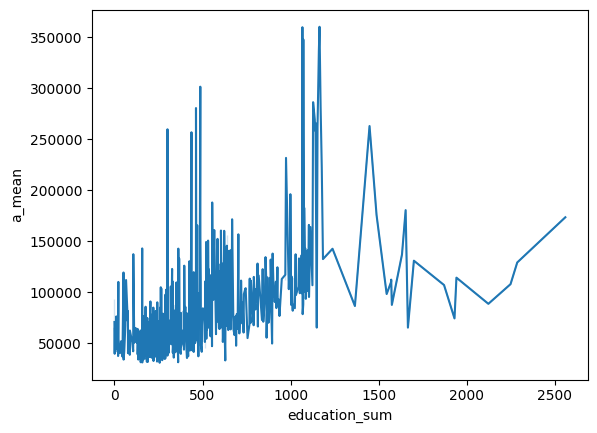

In [23]:
fig, ax = plt.subplots()
_ = sns.lineplot(x='education_sum', y='a_mean', data=condensed_df)
plt.show()

In [24]:
high_earn_df = condensed_df[condensed_df['a_mean'] >= 150000]

In [25]:
high_earn_df.reset_index()

,index,onetsoc_code,education_sum,occ_code,occupation_title,a_mean,h_mean
0,0,11-9121,2559.99,11-9120,Natural Sciences Managers,173500.0,83.41
1,1,11-9121,2559.99,11-9120,Clinical Research Coordinators,173500.0,83.41
2,2,11-9121,2559.99,11-9120,Water Resource Specialists,173500.0,83.41
3,388,11-3031,1653.24,11-3030,Financial Managers,180470.0,86.76
4,389,11-3031,1653.24,11-3030,Treasurers and Controllers,180470.0,86.76
5,390,11-3031,1653.24,11-3030,Investment Fund Managers,180470.0,86.76
6,568,11-9041,1488.08,11-9040,Architectural and Engineering Managers,175710.0,84.48
7,569,11-9041,1488.08,11-9040,Biofuels/Biodiesel Technology and Product Deve...,175710.0,84.48
8,592,11-1011,1448.26,11-1010,Chief Executives,262930.0,126.41
9,593,11-1011,1448.26,11-1010,Chief Sustainability Officers,262930.0,126.41


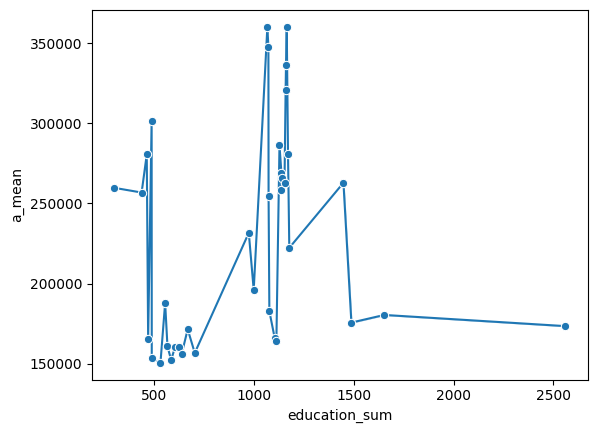

In [26]:
fig, ax = plt.subplots()
_ = sns.lineplot(x='education_sum', y='a_mean', data=high_earn_df, marker='o')

# Loop through the data to add labels from another column
#for i in range(high_earn_df.shape[0]):
#    if (i % 4 == 0):
#        plt.text(x=high_earn_df['education_sum'].iloc[i] + 0.1,  # Offset x to the right
#                 y=high_earn_df['a_mean'].iloc[i] + 0.1,  # Offset y slightly up
#                 s=high_earn_df['occupation_title'].iloc[i],    # The text from your other column
#                 fontdict=dict(color='red', size=10))
plt.show()

In [27]:
high_earn_df[['occupation_title', 'education_sum', 'a_mean']].sort_values(by='education_sum', ascending=True)

,occupation_title,education_sum,a_mean
5400,Athletes and Sports Competitors,301.10,259750.0
4182,Family Medicine Physicians,437.26,256830.0
4002,"Airline Pilots, Copilots, and Flight Engineers",462.95,280570.0
3967,"Agents and Business Managers of Artists, Perfo...",469.90,165600.0
3869,"Ophthalmologists, Except Pediatric",487.38,301500.0
3858,Petroleum Engineers,488.04,153560.0
3547,Purchasing Managers,531.60,150630.0
3273,Computer and Information Systems Managers,555.03,187990.0
3213,Sales Managers,566.66,160930.0
3118,Computer and Information Research Scientists,585.26,152310.0


For all of these multiple instances issues with different titles, I need to go back, figure out if these are the ones that went from detailed to broad, and then insert the broad occupation title. Then, here, drop any duplicates and see what's left.

We'll want to go back and keep occ_title. If the onetsoc_code and occ_code are the same, keep ONET title. If they're different, keep BLS title.

Put this in a new column, accepted title.

Then, go back and drop duplicates by [onetsoc_code, accpeted title].